# Data Preparation Listing Produk Tokopedia

Notebook ini membersihkan data listing produk berdasarkan masalah yang ditemukan di `01_eksplorasi_produk.ipynb`. Hasilnya disimpan sebagai `Dataset/processed/produk_bersih.csv`, yang nanti dipakai oleh notebook analisis dan dashboard.

1. Menyeragamkan nama kolom
2. Membuang baris duplikat
3. Membuang produk berharga 0
4. Mengubah `Terjual` dan `Jumlah Ulasan` menjadi angka
5. Mengubah rating 0 menjadi kosong
6. Merapikan lokasi dan menambahkan kolom kota dan provinsi
7. Membuat kolom kategori dari nama produk
8. Pemeriksaan akhir dan menyimpan hasil

In [1]:
import sys
from pathlib import Path

# Folder utama proyek dimasukkan ke daftar pencarian modul, supaya folder src bisa di-import
sys.path.append(str(Path("..").resolve()))

import inspect
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.produk import FRASA_KHUSUS, KATEGORI, rapikan_lokasi, tentukan_kategori, ubah_ke_angka

Fungsi-fungsi data prep di notebook ini disimpan di file `src/produk.py`, supaya bisa dipakai ulang oleh `run_pipeline.py` dan diuji otomatis oleh folder `tests/`. Notebook ini menjelaskan alasan setiap langkah dan menampilkan isi fungsinya dengan `inspect.getsource`.

In [2]:
# Gaya grafik, sama dengan notebook eksplorasi
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})

## 1. Muat data dan seragamkan nama kolom

Nama kolom diubah menjadi huruf kecil tanpa spasi dan tanda kurung, supaya lebih mudah ditulis di kode, misalnya `df["harga"]` dan bukan `df["Harga (IDR)"]`.

Variabel `jejak` mencatat jumlah baris setelah setiap langkah, supaya di akhir terlihat berapa banyak data yang berkurang dan karena apa.

In [3]:
df = pd.read_csv("../Dataset/raw/produk_tokopedia.csv")

df = df.rename(columns={
    "Nama Produk": "nama_produk",
    "Nama Toko": "nama_toko",
    "Lokasi Toko": "lokasi_toko",
    "Terjual": "terjual_teks",
    "Jumlah Ulasan": "ulasan_teks",
    "Rating": "rating",
    "Harga (IDR)": "harga",
    "Diskon (%)": "diskon",
    "Produk URL": "url",
})

jejak = {"Data awal": len(df)}
df.head()

,nama_produk,nama_toko,lokasi_toko,terjual_teks,ulasan_teks,rating,harga,diskon,url
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0,35000,0.0,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0,79999,0.0,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0,33000,0.0,https://www.tokopedia.com/rumahbully/chicken-m...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG F...,RumahBully,Tangerang Selatan,100+ terjual,NaN,5.0,29900,0.0,https://www.tokopedia.com/rumahbully/promo-bul...
4,Premium Dog Food / Daging Sapi Giling / Raw Fo...,RumahBully,Jakarta Selatan,1rb+ terjual,NaN,5.0,39000,0.0,https://www.tokopedia.com/rumahbully/premium-d...


## 2. Buang baris duplikat

Yang dibuang hanya baris yang isinya persis sama di semua kolom. Duplikat tidak dicari berdasarkan URL, karena sekitar 34% URL hanya berisi link halaman toko sehingga produk yang berbeda bisa punya URL yang sama (lihat notebook eksplorasi bagian 5).

In [4]:
sebelum = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Baris dibuang:", sebelum - len(df))

jejak["Setelah buang duplikat"] = len(df)

Baris dibuang: 416


## 3. Buang produk berharga 0

Harga 0 kemungkinan terjadi karena harga gagal terambil saat scraping. Baris ini dibuang, bukan diisi, karena harga adalah kolom utama analisis dan tidak ada cara yang wajar untuk menebaknya.

Produk dengan harga sangat tinggi (mobil, emas, dan sejenisnya) tetap disimpan karena datanya valid. Pengaruhnya diatasi saat analisis dengan memakai median.

In [5]:
harga_nol = df["harga"] == 0
print("Produk berharga 0:", harga_nol.sum())
df = df[~harga_nol].reset_index(drop=True)

jejak["Setelah buang harga 0"] = len(df)

Produk berharga 0: 35


## 4. Ubah `Terjual` dan `Jumlah Ulasan` menjadi angka

Aturan konversinya:

- Satuan `rb` dan `k` berarti ribu, `jt` berarti juta.
- Kalau ada satuan, titik atau koma adalah tanda desimal. Jadi "1.2rb" dan "1,2 rb" sama-sama menjadi 1.200.
- Kalau tidak ada satuan, titik atau koma adalah pemisah ribuan. Jadi "1.000" menjadi 1000.
- Tanda `+` diabaikan. Artinya "1rb+" menjadi 1000, yang harus dibaca sebagai "minimal 1.000".
- Teks yang tidak berisi jumlah, seperti "Best Seller", "Unknown", atau "103 rating" di kolom terjual, menjadi kosong.

Pola teksnya ditulis dengan regular expression (regex). Bagian-bagiannya:

- `(\d[\d.,]*)` mengambil angka, termasuk titik dan koma di dalamnya.
- `(rb|jt|k)?` mengambil satuan, kalau ada.
- `\+?` menerima tanda plus, kalau ada.
- `(?:{kata})?` menerima kata penutup seperti "terjual" atau "ulasan".
- `^` dan `$` memastikan seluruh teks harus cocok, sehingga "150 stok" tidak ikut terbaca sebagai jumlah terjual.

In [6]:
# Isi fungsi ubah_ke_angka dari src/produk.py
print(inspect.getsource(ubah_ke_angka))

def ubah_ke_angka(teks, kata):
    """Mengubah teks seperti '1rb+ terjual' menjadi angka. Hasilnya NaN kalau teks bukan jumlah."""
    if pd.isna(teks):
        return np.nan
    cocok = re.match(POLA_ANGKA.format(kata=kata), teks.strip().lower())
    if cocok is None:
        return np.nan
    angka, satuan = cocok.group(1), cocok.group(2)
    if satuan:
        # Ada satuan: titik atau koma adalah desimal (1.2rb = 1.200)
        return round(float(angka.replace(",", ".")) * PENGALI[satuan])
    # Tanpa satuan: titik atau koma adalah pemisah ribuan (1.000 = 1000)
    return float(angka.replace(".", "").replace(",", ""))



Sebelum dipakai ke seluruh data, fungsinya diuji dulu dengan contoh-contoh yang ditemukan saat eksplorasi. Kolom `harapan` berisi hasil yang seharusnya.

In [7]:
contoh = pd.DataFrame([
    ("26 terjual", "terjual", 26),
    ("100+ terjual", "terjual", 100),
    ("1rb+ terjual", "terjual", 1_000),
    ("4 rb+ Terjual", "terjual", 4_000),
    ("4.95rb+ terjual", "terjual", 4_950),
    ("1jt+ terjual", "terjual", 1_000_000),
    ("223 sold", "terjual|sold", 223),
    ("150 stok", "terjual", np.nan),
    ("Best Seller", "terjual", np.nan),
    ("1.000 ulasan", "ulasan", 1_000),
    ("7.426 ulasan", "ulasan", 7_426),
    ("1.2rb ulasan", "ulasan", 1_200),
    ("1,3 rb ulasan", "ulasan", 1_300),
    ("1.5K ulasan", "ulasan", 1_500),
    ("1,6 rb ulasan toko", "ulasan", np.nan),
    ("Tidak tersedia", "ulasan", np.nan),
], columns=["teks", "kata", "harapan"])

contoh["hasil"] = [ubah_ke_angka(t, k) for t, k in zip(contoh["teks"], contoh["kata"])]
contoh["sesuai"] = (contoh["hasil"] == contoh["harapan"]) | (contoh["hasil"].isna() & contoh["harapan"].isna())
contoh

,teks,kata,harapan,hasil,sesuai
0,26 terjual,terjual,26.0,26.0,True
1,100+ terjual,terjual,100.0,100.0,True
2,1rb+ terjual,terjual,1000.0,1000.0,True
3,4 rb+ Terjual,terjual,4000.0,4000.0,True
4,4.95rb+ terjual,terjual,4950.0,4950.0,True
5,1jt+ terjual,terjual,1000000.0,1000000.0,True
6,223 sold,terjual|sold,223.0,223.0,True
7,150 stok,terjual,NaN,NaN,True
8,Best Seller,terjual,NaN,NaN,True
9,1.000 ulasan,ulasan,1000.0,1000.0,True


In [8]:
assert contoh["sesuai"].all(), "Ada contoh yang hasilnya tidak sesuai"

Semua contoh sesuai. Fungsinya lalu dipakai ke seluruh data. Kolom hasil memakai tipe `Int64` (dengan huruf I besar), yaitu tipe bilangan bulat di pandas yang bisa menyimpan nilai kosong.

In [9]:
df["terjual"] = df["terjual_teks"].map(lambda t: ubah_ke_angka(t, "terjual|sold")).astype("Int64")
df["jumlah_ulasan"] = df["ulasan_teks"].map(lambda t: ubah_ke_angka(t, "(?:total )?ulasan")).astype("Int64")

for kolom_teks, kolom_angka in [("terjual_teks", "terjual"), ("ulasan_teks", "jumlah_ulasan")]:
    gagal = df[kolom_teks].notna() & df[kolom_angka].isna()
    print(f"{kolom_angka}: {df[kolom_angka].notna().sum():,} berhasil, {gagal.sum()} teks bukan jumlah")

terjual: 28,700 berhasil, 142 teks bukan jumlah


jumlah_ulasan: 27,396 berhasil, 431 teks bukan jumlah


In [10]:
# Teks terjual yang tidak berhasil diubah, untuk memastikan tidak ada angka yang terlewat
gagal = df["terjual_teks"].notna() & df["terjual"].isna()
df.loc[gagal, "terjual_teks"].value_counts().head(15)

terjual_teks
Unknown                   22
Tidak tersedia            19
Baru                      17
Terjual                   14
Tidak disebutkan          14
Terlaris                   8
tersedia                   7
terjual                    6
Tidak ada data             6
Not available              4
Terjual tidak tersedia     3
Terjual banyak             2
Best Seller                2
Terjual Sebagian           2
Stock Tersedia             1
Name: count, dtype: int64

In [11]:
gagal = df["ulasan_teks"].notna() & df["jumlah_ulasan"].isna()
df.loc[gagal, "ulasan_teks"].value_counts().head(15)

ulasan_teks
Tidak tersedia           113
Tidak disebutkan          79
Tidak ada data            57
Unknown                   34
N/A ulasan                33
tersedia                  19
Ulasan tersedia           15
Data tidak tersedia       15
Not available             11
not specified              7
ulasan tersedia            7
Ribuan ulasan              6
Ratusan ulasan             5
Belum ada ulasan           3
Ulasan tidak tersedia      3
Name: count, dtype: int64

Yang gagal diubah memang bukan jumlah, misalnya "Unknown", "Tidak tersedia", "Ribuan ulasan", dan "Terlaris". Nilai seperti "Ribuan ulasan" sebenarnya memberi petunjuk, tapi tidak bisa diubah menjadi satu angka yang jujur, jadi dibiarkan kosong.

In [12]:
df = df.drop(columns=["terjual_teks", "ulasan_teks"])
df[["terjual", "jumlah_ulasan"]].describe()

,terjual,jumlah_ulasan
count,28700.0,27396.0
mean,2330.740453,769.972441
std,24383.232929,9516.702852
min,0.0,0.0
25%,6.0,0.0
50%,50.0,10.0
75%,250.0,90.0
max,1000000.0,1000000.0


## 5. Ubah rating 0 menjadi kosong

Rating 0 berarti produk belum dinilai, bukan rating terburuk. Kalau dibiarkan, rata-rata rating akan turun secara tidak wajar. Baris produknya tetap disimpan karena data harga dan lokasinya masih berguna.

In [13]:
rating_nol = df["rating"] == 0
print("Rating 0 diubah menjadi kosong:", rating_nol.sum())
df.loc[rating_nol, "rating"] = np.nan
df["rating"].describe()

Rating 0 diubah menjadi kosong: 1930


count    27138.000000
mean         4.901539
std          0.202170
min          1.000000
25%          4.900000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

## 6. Rapikan lokasi, tambahkan kota dan provinsi

Langkahnya:

1. Ambil bagian sebelum koma, jadi "Bekasi, Jawa Barat" menjadi "Bekasi".
2. Buang awalan "Kota Administrasi", "Kota", "Kab.", dan "Kabupaten".
3. Satukan Jakarta Barat, Timur, Utara, Selatan, dan Pusat menjadi "Jakarta", karena banyak data yang hanya ditulis "Jakarta".
4. Cocokkan dengan tabel referensi `Dataset/raw/referensi_kota_provinsi.csv` untuk mendapatkan kota dan provinsi.

Akibat langkah 2, Kota Bandung dan Kabupaten Bandung tergabung menjadi "Bandung". Ini disengaja, karena banyak data yang hanya menulis "Bandung" tanpa keterangan kota atau kabupaten. Keduanya tetap berada di provinsi yang sama.

Lokasi yang bukan nama tempat, seperti "Indonesia", "Online", dan "Tokopedia", tidak ada di tabel referensi sehingga kota dan provinsinya kosong. "Banjar" juga dibiarkan kosong karena bisa berarti Kota Banjar (Jawa Barat) atau Kabupaten Banjar (Kalimantan Selatan).

In [14]:
# Isi fungsi rapikan_lokasi dari src/produk.py
print(inspect.getsource(rapikan_lokasi))

referensi = pd.read_csv("../Dataset/raw/referensi_kota_provinsi.csv")
referensi.head(10)

def rapikan_lokasi(teks):
    """Menyeragamkan nama lokasi, misalnya 'Kota Administrasi Jakarta Barat' menjadi 'Jakarta'."""
    if pd.isna(teks):
        return np.nan
    teks = teks.split(",")[0].strip()
    teks = re.sub(r"^(Kota Administrasi|Kota Adm\.?|Kabupaten|Kab\.?|Kota)\s+", "", teks, flags=re.IGNORECASE)
    teks = re.sub(r"^Jakarta\s+(Barat|Timur|Utara|Selatan|Pusat)$", "Jakarta", teks)
    return teks.strip()



,lokasi,kota,provinsi
0,Jakarta,Jakarta,DKI Jakarta
1,DKI Jakarta,Jakarta,DKI Jakarta
2,Jakarta Administrasi,Jakarta,DKI Jakarta
3,Menteng,Jakarta,DKI Jakarta
4,Pancoran,Jakarta,DKI Jakarta
5,Cibubur,Jakarta,DKI Jakarta
6,Tangerang,Tangerang,Banten
7,Tangerang Selatan,Tangerang Selatan,Banten
8,Serang,Serang,Banten
9,Cilegon,Cilegon,Banten


In [15]:
df["lokasi_rapi"] = df["lokasi_toko"].map(rapikan_lokasi)
df = df.merge(referensi, left_on="lokasi_rapi", right_on="lokasi", how="left")
df = df.drop(columns=["lokasi_rapi", "lokasi"])

print("Jumlah kota unik    :", df["kota"].nunique())
print("Jumlah provinsi unik:", df["provinsi"].nunique())
print("Provinsi tidak diketahui:", df["provinsi"].isna().sum(), "baris")

Jumlah kota unik    : 149
Jumlah provinsi unik: 32
Provinsi tidak diketahui: 3072 baris


In [16]:
# Lokasi asli yang tidak punya provinsi
df.loc[df["provinsi"].isna(), "lokasi_toko"].value_counts(dropna=False).head(10)

lokasi_toko
Indonesia            2781
NaN                   139
Unknown                53
Tidak disebutkan       12
Tokopedia              11
Nasional               11
Unknown Location       10
Jabodetabek             9
Seluruh Indonesia       7
Online                  6
Name: count, dtype: int64

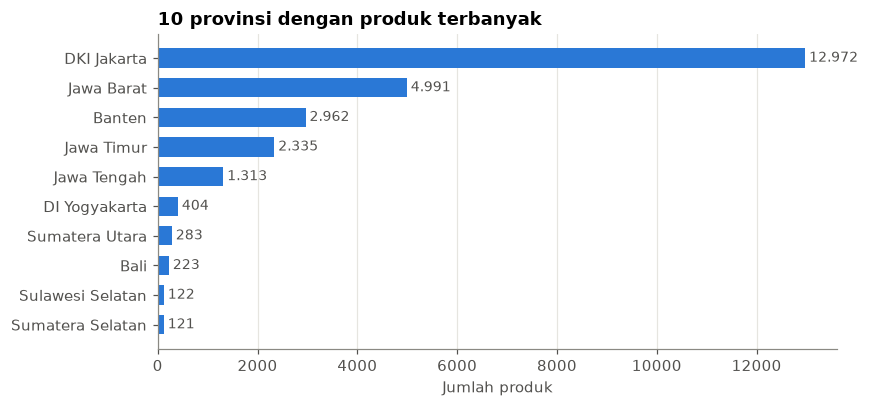

In [17]:
prov = df["provinsi"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(prov.index, prov.values, color=BIRU, height=0.65)
for y, v in enumerate(prov.values):
    ax.text(v + 80, y, f"{v:,}".replace(",", "."), va="center", fontsize=9, color=TEKS)
ax.set_title("10 provinsi dengan produk terbanyak")
ax.set_xlabel("Jumlah produk")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 7. Buat kolom kategori dari nama produk

Dataset tidak punya kolom kategori, jadi kategori ditentukan dari kata kunci di nama produk. Model machine learning tidak bisa dipakai di sini, karena tidak ada contoh produk yang sudah berlabel kategori untuk dipelajari.

Cara kerjanya dua lapis:

1. **Frasa khusus** dicek paling awal. Isinya frasa yang maknanya jelas tetapi akan salah golong kalau hanya mengandalkan kata tunggal. Contohnya "mobil mobilan" (mainan, bukan otomotif), "rak sepatu" (rumah tangga, bukan fashion), "charger laptop" (elektronik, bukan handphone), dan "alexandre christie" (merek jam tangan yang kodenya diawali "AC", bukan AC pendingin ruangan).
2. Kalau tidak ada frasa khusus yang cocok, dipakai **kata kunci per kategori**. Produk masuk ke kategori pertama yang kata kuncinya muncul, jadi urutan kategori berpengaruh. Contohnya, "Dog Food" dicek lebih dulu di Hewan Peliharaan sebelum dicek di Makanan & Minuman.

Produk yang tidak cocok dengan apa pun masuk "Lainnya".

Kata kunci dicocokkan sebagai kata utuh (`\b` di regex), jadi "tas" tidak ikut cocok dengan kata "kualitas". Beberapa kata sengaja tidak dipakai karena terlalu ambigu. Contohnya "pet" (juga berarti plastik PET pada toples, helm, dan hijab) dan "softcase" (dipakai untuk casing HP, tetapi juga tas laptop dan koper).

Lima kategori dari dataset ulasan (Elektronik, Fashion, Olahraga, Handphone, Pertukangan) sengaja disertakan, supaya kedua dataset bisa disandingkan di level kategori.

Daftar kata kunci ini disusun dalam tiga putaran. Setiap usulan perubahan diuji ke seluruh produk, lalu produk yang berpindah kategori diperiksa satu per satu, supaya perubahan yang memperbaiki satu kasus tidak merusak kasus lain. Akurasinya diukur di bagian 7a.

In [18]:
# Kamus lengkap ada di src/produk.py. Di sini ditampilkan jumlah dan contoh kata kuncinya.
print("Frasa khusus (dicek paling awal):")
display(pd.DataFrame({
    "jumlah_frasa": {kat: len(kata) for kat, kata in FRASA_KHUSUS.items()},
    "contoh": {kat: ", ".join(kata[:5]) for kat, kata in FRASA_KHUSUS.items()},
}))
print("Kata kunci per kategori, sesuai urutan pengecekan:")
pd.DataFrame({
    "jumlah_kata_kunci": {kat: len(kata) for kat, kata in KATEGORI.items()},
    "contoh": {kat: ", ".join(kata[:6]) for kat, kata in KATEGORI.items()},
})

Frasa khusus (dicek paling awal):


,jumlah_frasa,contoh
"Ibu, Bayi & Mainan",10,"mobil mobilan, mobilan, diecast, hot wheels, h..."
Elektronik,12,"smartwatch, smart watch, jam tangan pintar, va..."
Rumah Tangga,18,"rak sepatu, sarung bantal, gantungan baju, kan..."
Hewan Peliharaan,4,"pelet ikan, makanan ikan, pakan ikan, pakan bu..."
Kesehatan & Kecantikan,5,"bibit parfum, eyeshadow, sarung tangan plastik..."
Handphone,5,"car charger, charger mobil, charger hp, holder..."
Fashion,4,"jam tangan, alexandre christie, alexander chri..."
Pertukangan,5,"lantai spc, spc floor, pintu aluminium, balok ..."
Otomotif,2,"karpet mobil, tankpad"


Kata kunci per kategori, sesuai urutan pengecekan:


,jumlah_kata_kunci,contoh
Hewan Peliharaan,21,"dog, cat food, cat litter, kucing, anjing, whi..."
Otomotif,28,"motor, mobil, helm, oli, ban, velg"
Handphone,19,"hp, handphone, smartphone, iphone, galaxy, xiaomi"
Elektronik,61,"laptop, mouse, keyboard, monitor, speaker, sou..."
Perhiasan,11,"cincin, gelang, kalung, anting, emas, perak"
Olahraga,27,"jersey, sepeda, raket, futsal, badminton, yoga"
"Ibu, Bayi & Mainan",19,"mainan, boneka, lego, puzzle, action figure, bayi"
Fashion,75,"baju, kaos, kemeja, celana, jaket, hoodie"
Kesehatan & Kecantikan,83,"serum, skincare, lipstik, lip, cushion, bedak"
Makanan & Minuman,58,"kopi, teh, snack, keripik, kripik, sambal"


In [19]:
df["kategori"] = df["nama_produk"].map(tentukan_kategori)
df["kategori"].value_counts()

kategori
Fashion                   5458
Rumah Tangga              4805
Elektronik                4308
Kesehatan & Kecantikan    3662
Lainnya                   2411
Makanan & Minuman         1562
Perhiasan                 1183
Pertukangan                996
Otomotif                   973
Buku & Alat Tulis          880
Handphone                  861
Olahraga                   847
Ibu, Bayi & Mainan         843
Hewan Peliharaan           279
Name: count, dtype: int64

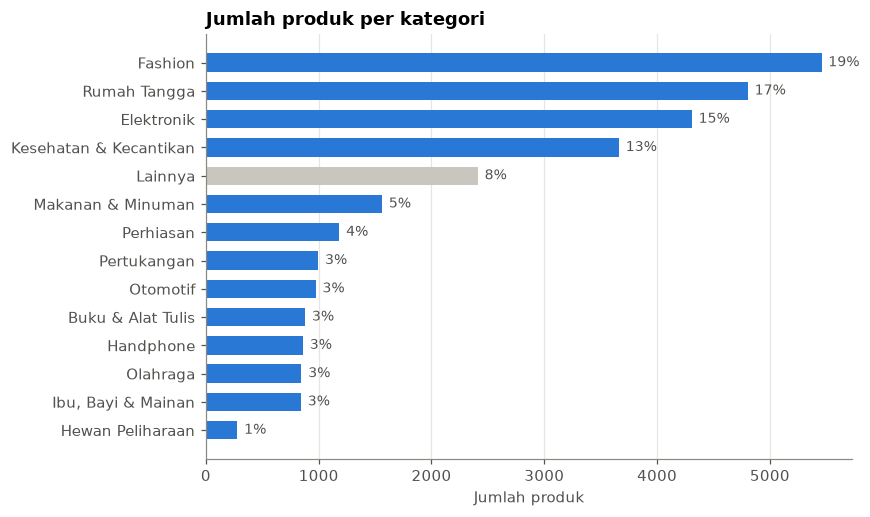

In [20]:
kat = df["kategori"].value_counts().sort_values()
warna = [ABU if k == "Lainnya" else BIRU for k in kat.index]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(kat.index, kat.values, color=warna, height=0.65)
for y, v in enumerate(kat.values):
    ax.text(v + 60, y, f"{v / len(df):.0%}", va="center", fontsize=9, color=TEKS)
ax.set_title("Jumlah produk per kategori")
ax.set_xlabel("Jumlah produk")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Pemeriksaan manual: tiga contoh acak dari setiap kategori, untuk melihat apakah kategorinya masuk akal.

In [21]:
with pd.option_context("display.max_colwidth", 80):
    display(df.groupby("kategori").sample(3, random_state=1)[["kategori", "nama_produk"]])

,kategori,nama_produk
346,Buku & Alat Tulis,AZKO Forhom Cermin Dinding Stiker Wall Mirror
12634,Buku & Alat Tulis,KERTAS LABEL BARCODE BLUEPRINT UK 102MM X 127MM 1LINE BP-DTS1021271
6159,Buku & Alat Tulis,SHENAR RAK BUKU PORTABLE-RAK BUKU-LEMARI SERBAGUNA 2SISI BLUE FLOWER
24982,Elektronik,TOKO EBES Senter Kepala LED COB Lampu Headlamp Flashlight Hiking Camping
4545,Elektronik,EGGEL Home 3 Portable Bluetooth Speaker with Karaoke Function
4457,Elektronik,Vacuum Cleaner Mobil Penyedot Debu dalam Mobil 12V
28124,Fashion,Kacamata Minus 0.50 s/d 4.00 Rabun Jauh Frame Gantung Titanium Lensa Pria Vi...
14885,Fashion,Parfum Sepatu / Pewangi Anti Bakteri Shoe Perfume Pengharum Sepatu Active
19182,Fashion,TOTE BAG WANITA SEPATU MURAH ( PAKAI RESLETING )
24927,Handphone,Kabel Data Esia MP4 Nexian Mito USB Cable Mini B Kualitas Terbaik Ready Stock


### 7a. Seberapa akurat kategorinya?

Contoh acak di atas hanya memberi gambaran kasar. Untuk mendapatkan angka akurasi, 200 produk diambil secara acak, lalu kategori yang seharusnya untuk setiap produk ditentukan manual dengan membaca nama produknya. Hasilnya disimpan di `Dataset/manual/cek_kategori_manual.csv`.

Beberapa aturan penilaian:

- Kategori dianggap benar kalau masuk akal untuk produk itu. Kalau dua kategori sama-sama masuk akal, misalnya kunci pintu di Pertukangan atau Rumah Tangga, keduanya dianggap benar.
- Produk di "Lainnya" dihitung terpisah, karena "Lainnya" artinya belum tergolong, bukan salah golong.
- Sampel ini diambil setelah aturan kategori selesai disusun, dan tidak dipakai untuk mengubah aturan. Sampel lain yang dipakai untuk mencari kesalahan saat menyusun aturan tidak ikut dinilai di sini. Kalau sampel yang sama dipakai untuk menyusun dan menilai, akurasinya akan terlihat lebih tinggi dari kenyataan.

Kategori dihitung ulang dengan fungsi `tentukan_kategori` yang sekarang, jadi angka di bawah otomatis mengikuti kalau aturan kategori diubah lagi. Kolom `kategori_versi_awal` berisi hasil aturan sebelum diperbaiki, sebagai pembanding.

In [22]:
cek_manual = pd.read_csv("../Dataset/manual/cek_kategori_manual.csv")
cek_manual["kategori_aturan"] = cek_manual["nama_produk"].map(tentukan_kategori)


def ringkas(tebakan, benar):
    ada = tebakan != "Lainnya"
    n, p = ada.sum(), (benar & ada).sum() / ada.sum()
    batas = 1.96 * (p * (1 - p) / n) ** 0.5  # kisaran 95%, pendekatan normal
    return {
        "masuk Lainnya": int((~ada).sum()),
        "diberi kategori": int(n),
        "benar (dari yang diberi kategori)": f"{p:.1%}",
        "kisaran 95%": f"{p - batas:.0%} - {p + batas:.0%}",
        "benar (dari 200)": f"{benar.mean():.1%}",
    }


pd.DataFrame({
    "versi awal": ringkas(cek_manual["kategori_versi_awal"], cek_manual["versi_awal_benar"]),
    "versi sekarang": ringkas(cek_manual["kategori_aturan"], cek_manual["kategori_aturan"] == cek_manual["kategori_seharusnya"]),
}).T

,masuk Lainnya,diberi kategori,benar (dari yang diberi kategori),kisaran 95%,benar (dari 200)
versi awal,17,183,83.6%,78% - 89%,77.0%
versi sekarang,12,188,89.9%,86% - 94%,85.0%


Produk yang masih salah golong atau masih di "Lainnya" pada sampel ini:

In [23]:
salah = cek_manual[cek_manual["kategori_aturan"] != cek_manual["kategori_seharusnya"]]
with pd.option_context("display.max_colwidth", 70, "display.max_rows", 50):
    display(salah[["nama_produk", "kategori_aturan", "kategori_seharusnya"]])

,nama_produk,kategori_aturan,kategori_seharusnya
7,NANAS PALEMBANG (KUPAS & GILING/PARUT),Lainnya,Makanan & Minuman
10,Kompor Gas 1 tungku sanex FREE SELANG REGULATOR,Pertukangan,Rumah Tangga
37,Benih Buah Penyegar 5 Macam Benih Paket Buah-Buahan Segar Seribuan,Makanan & Minuman,Rumah Tangga
47,Nano Block Serangga dan hewan laut dinosaurus hewan ternak lucu,Lainnya,"Ibu, Bayi & Mainan"
48,HUGO Payung Tenda 200 cm Jualan Taman Pantai Cafe Bazar Lapak,Olahraga,Rumah Tangga
53,"Tas Selempang Pria Wanita 1420 - Slingbag Uniseks Muat Laptop 14""",Elektronik,Fashion
55,1 PACK 10 PCS BUKU TULIS SIDU COVER COKLAT 40 LEMBAR,Makanan & Minuman,Buku & Alat Tulis
60,Homesleeping - Sarung Guling 30x90 / 30x100 Plain / Polos Minimalis,Fashion,Rumah Tangga
64,NEW ACE KRIS PARUTAN DENGAN KERANJANG WADAH ALAT PARUT GRATER PEMA...,Makanan & Minuman,Rumah Tangga
84,VIRAL DAN PALING LARISSS!!! Jam Tangan Android Whatsapp Pintar,Fashion,Elektronik


Sekitar 9 dari 10 produk yang diberi kategori tergolong dengan benar. Karena sampelnya hanya 200, angka sebenarnya bisa beberapa poin di atas atau di bawah itu (lihat kolom kisaran 95%). Kisaran versi awal dan versi sekarang juga masih sedikit bertumpuk. Artinya perbaikannya terlihat, tetapi sampel 200 produk belum cukup untuk membuktikannya secara statistik. Bukti yang lebih kuat datang dari pemeriksaan per perubahan: setiap produk yang berpindah kategori sudah diperiksa, dan hampir semua perpindahannya ke kategori yang lebih tepat.

Kesalahan yang tersisa kebanyakan berasal dari satu kata yang tertangkap kategori yang dicek lebih dulu. Contohnya "coklat" pada sampul buku tulis (masuk Makanan & Minuman), "jersey" pada jilbab olahraga (masuk Olahraga), "laptop" pada tas selempang (masuk Elektronik), dan "kucing" pada motif kaos kaki (masuk Hewan Peliharaan). Setiap kasus seperti ini bisa ditambal dengan frasa khusus, tetapi setiap tambalan juga berisiko memindahkan produk lain. Untuk kebutuhan analisis di notebook ini, yang membandingkan median harga dan penjualan antar kategori, akurasi sekitar 90% sudah memadai. Median tidak mudah bergeser oleh sebagian kecil produk yang salah golong.

## 8. Pemeriksaan akhir dan simpan

Kolom diurutkan supaya mudah dibaca. Kolom `lokasi_toko` yang asli tetap disimpan, supaya hasil pemetaan kota dan provinsi bisa dicek ulang.

In [24]:
df = df[[
    "nama_produk", "kategori", "nama_toko", "lokasi_toko", "kota", "provinsi",
    "harga", "diskon", "terjual", "jumlah_ulasan", "rating", "url",
]]
jejak["Data bersih"] = len(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29068 entries, 0 to 29067
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   nama_produk    29068 non-null  str    
 1   kategori       29068 non-null  str    
 2   nama_toko      29018 non-null  str    
 3   lokasi_toko    28929 non-null  str    
 4   kota           25950 non-null  str    
 5   provinsi       25996 non-null  str    
 6   harga          29068 non-null  int64  
 7   diskon         29068 non-null  float64
 8   terjual        28700 non-null  Int64  
 9   jumlah_ulasan  27396 non-null  Int64  
 10  rating         27138 non-null  float64
 11  url            29068 non-null  str    
dtypes: Int64(2), float64(2), int64(1), str(7)
memory usage: 8.1 MB


In [25]:
df.isna().sum()

nama_produk         0
kategori            0
nama_toko          50
lokasi_toko       139
kota             3118
provinsi         3072
harga               0
diskon              0
terjual           368
jumlah_ulasan    1672
rating           1930
url                 0
dtype: int64

In [26]:
df.to_csv("../Dataset/processed/produk_bersih.csv", index=False)

# Baca ulang untuk memastikan file tersimpan dengan benar
cek = pd.read_csv("../Dataset/processed/produk_bersih.csv")
print(cek.shape)

(29068, 12)


In [27]:
pd.Series(jejak, name="jumlah baris").to_frame()

,jumlah baris
Data awal,29519
Setelah buang duplikat,29103
Setelah buang harga 0,29068
Data bersih,29068


## Ringkasan

Hubungan antara masalah di notebook eksplorasi dan penanganannya di sini:

| Masalah di eksplorasi | Penanganan |
|---|---|
| 1, 2, 3. `Terjual` dan `Jumlah Ulasan` masih teks, format angkanya tidak konsisten, dan ada nilai yang bukan jumlah | Diubah menjadi angka dengan fungsi `ubah_ke_angka`. Nilai yang bukan jumlah dijadikan kosong |
| 4. Nilai kosong | Dibiarkan kosong. Baris tidak dibuang karena kolom lain masih berguna |
| 5. Rating 0 | Diubah menjadi kosong |
| 6. Harga 0 | Barisnya dibuang |
| 7. Harga sangat tinggi | Disimpan. Ditangani saat analisis dengan median |
| 8. Baris duplikat | 416 baris yang persis sama dibuang |
| 9. Lokasi tidak seragam | Ditambahkan kolom `kota` dan `provinsi` dari tabel referensi |
| 10. Tidak ada kategori | Ditambahkan kolom `kategori` dari kata kunci nama produk |
| 11. Rating terkonsentrasi di angka tinggi | Tidak diubah. Menjadi catatan saat analisis |

Hal yang perlu diingat saat analisis:

- `terjual` dan `jumlah_ulasan` adalah batas bawah untuk nilai yang aslinya memakai tanda +.
- Kategori berbasis kata kunci tidak sempurna. Dari 200 produk acak yang diperiksa manual, sekitar 90% produk yang diberi kategori tergolong dengan benar, dan sekitar 8% produk masuk "Lainnya".
- Produk dengan provinsi kosong tidak diikutkan dalam analisis wilayah.